# Notebook 04 — confirmatory hypothesis tests (pre-registered)

## Pre-registered decision rule (fixed before this notebook ran)

This notebook executes **only** the confirmatory comparison list of
`reports/pre_registration.md` (pinned **2026-09-22**, commit **`35317bc`**,
before any confirmatory output existed). Nothing below may be tuned after the
fact; any departure would be an explicitly labelled post-hoc exploration
(§6 of the pre-registration), and **no deviation is recorded for this run**.

| Rule | Value (pre-reg §4–§5) |
|---|---|
| Significance level | **α = 0.05, two-sided** for every test |
| Family A multiplicity | 6 pairwise z-tests → **Bonferroni** α\* = 0.05/6 ≈ 0.0083 (rejection rule) |
| Sensitivity | **BH-FDR** reported for the same 6 pairs — sensitivity only, does **not** set rejection |
| Sparse rule | any cell with expected count < 5 → **no test**, `sparse=True`, rates reported descriptively |
| Practical gate (decision-relevant) | **all three**: 95% CI of the difference excludes 0, **and** \|relative uplift\| ≥ 10% of the lower rate, **and** affected volume ≥ 1% of sessions (≥ 45 360 of 4 535 941) |
| Affected-volume operand | for a pair: size of the **smaller** of the two compared groups (§5 gap note) |

**Two kinds of significance are kept separate** (golden standard): a test may
be *statistically* significant (p below its corrected threshold) yet *not*
decision-relevant under the practical gate — the verdict column below reports
the practical answer, never substitutes a bare p-value for it.

**By-design consequence (§5):** luxury holds 42 438 sessions = **0.94 %** of
all sessions — below the 1 % affected-volume bar — so in **every** comparison
it participates in it is **never decision-relevant**, even when statistically
confirmed. This notebook states that fact; it is not a surprise discovered
after the fact.

**Complete pre-registered inventory (nothing else runs):**

1. **Family A** — price tier × view→cart, on **view sessions** only
   (`has_view`), "NA" tier excluded with an explicit count:
   1 omnibus χ² (4×2) + **6** pairwise two-proportion z-tests.
2. **Family B** — visit kind × cart→purchase, on **cart sessions**: 1 z-test.
3. **Family C** — weekend/weekday × cart→purchase, on **cart sessions**: 1 z-test.

Overall funnel figures in notebooks 01/02 stay **descriptive** (pre-reg §1):
they carry no significance claim regardless of what this notebook finds.


In [1]:
import math
import os
import sys
from itertools import combinations
from pathlib import Path


def _find_repo_root() -> Path:
    """Resolve the repo root from the kernel's CWD (cwd-independent cell).

    The build runner launches the kernel from the repo root, but a reader who
    re-executes the .ipynb from another directory must resolve the same data.
    Walk up until a directory contains both src/ and the sessions artifact; the
    is_file() guard below fails loudly instead of silently loading wrong data.
    """
    probe = Path(os.getcwd()).resolve()
    for _ in range(8):
        if (probe / "src").is_dir() and (
            probe / "data" / "processed" / "sessions.parquet"
        ).is_file():
            return probe
        parent = probe.parent
        if parent == probe:
            break
        probe = parent
    raise RuntimeError(
        "repo root not found from CWD="
        + str(Path(os.getcwd()))
        + "; expected a dir with src/ and data/processed/sessions.parquet"
    )


REPO_ROOT = _find_repo_root()
sys.path.insert(0, str(REPO_ROOT))

SESSIONS_FILE = REPO_ROOT / "data" / "processed" / "sessions.parquet"

# Fail loudly if the processed artifact is missing — an empty session table
# would otherwise sail through and silently change every downstream number.
if not SESSIONS_FILE.is_file():
    raise FileNotFoundError(f"missing processed artifact: {SESSIONS_FILE}")

# Analysis lives in src only — the notebook renders, it does not re-implement
# test maths. src.plots import applies the shared matplotlib style, and the Agg
# backend set there is exactly what the headless forest-plot save needs.
import polars as pl  # noqa: E402
from IPython.display import Image, Markdown, display  # noqa: E402
from matplotlib import pyplot as plt  # noqa: E402
from src.inference import (  # noqa: E402
    bonferroni,
    chi2_independence,
    fdr_bh,
    two_prop_ztest,
    wilson_ci,
)
from src.segments import assign_segments  # noqa: E402
import src.plots  # noqa: E402,F401  (applies project style, sets Agg backend)
from src.plots import assets_path  # noqa: E402

# Pre-registered constants (reports/pre_registration.md §4–§5, commit 35317bc).
# Single assignment: every threshold check below reads these, not a re-typed
# literal that could drift between cells.
ALPHA = 0.05                 # two-sided, every test
ALPHA_STAR = ALPHA / 6       # Bonferroni for the 6 family-A pairwise tests
VOLUME_MIN = 45_360          # 1% of 4,535,941 sessions (§5)
PREREG_SHA = "35317bc"       # pinning commit of reports/pre_registration.md
N_PAIRWISE = 6               # (4 choose 2) — structural inventory of family A

print(f"repo root:    {REPO_ROOT}")
print(f"sessions:     {SESSIONS_FILE}")
print(f"pre-reg SHA:  {PREREG_SHA}  |  alpha={ALPHA}  |  alpha*={ALPHA_STAR:.6f}")


repo root:    /mnt/d/opencode/new20
sessions:     /mnt/d/opencode/new20/data/processed/sessions.parquet
pre-reg SHA:  35317bc  |  alpha=0.05  |  alpha*=0.008333


In [2]:
# One row per user_session, the frozen unit of the whole project.
sessions = pl.read_parquet(SESSIONS_FILE)
seg = assign_segments(sessions)
del sessions  # keep only the labelled frame; the raw frame is not needed again

print(f"loaded {seg.height:,} session rows")
print(f"view sessions:   {int(seg['has_view'].sum()):,}")
print(f"cart sessions:   {int(seg['has_cart'].sum()):,}")


loaded 4,535,941 session rows
view sessions:   4,280,701
cart sessions:   985,780


In [3]:
# Family A plane (pre-reg §3): view sessions only; the "NA" price tier
# (null median_price) is excluded with an explicit count — pre-reg requires
# it never silently disappears from the comparison.
view = seg.filter(pl.col("has_view") & (pl.col("price_tier") != "NA"))
n_na_view = int(
    seg.filter(pl.col("has_view") & (pl.col("price_tier") == "NA")).height
)

# Merchandising tier order, fixed in pre-reg §2 (not sorted by observed rate —
# ordering the table by outcome would be silent post-hoc styling).
TIERS = ["budget", "mid", "premium", "luxury"]

# Per-tier view->cart counts. Inside the has_view filter, has_cart marks a
# view session that also reached cart — the view->cart numerator of §1.
# wilson_ci reports sampling uncertainty of each observed rate (descriptive
# context around the omnibus test, not a second hypothesis).
tier_stats: dict[str, dict] = {}
for _t in TIERS:
    _sub = view.filter(pl.col("price_tier") == _t)
    _cart = int(_sub["has_cart"].sum())
    _n = _sub.height
    if _n == 0:
        # Empty denominator makes the rate undefined; fail fast instead of
        # dividing by zero and printing a plausible-looking nan.
        raise ValueError(f"tier {_t!r} has no view sessions; cannot test")
    _lo, _hi = wilson_ci(_cart, _n)
    tier_stats[_t] = {
        "cart": _cart, "n": _n, "rate": _cart / _n,
        "ci_low": _lo, "ci_high": _hi,
    }

# 4x2 contingency: rows = tiers (pre-reg order), cols = [reached cart, not].
contingency = [
    [tier_stats[t]["cart"], tier_stats[t]["n"] - tier_stats[t]["cart"]]
    for t in TIERS
]
chi2_res = chi2_independence(contingency)

# Structural fidelity check: dof = (rows-1)*(cols-1) = 3 iff the omnibus
# really spans the four pre-registered tiers — a wrong-shaped table cannot
# silently masquerade as the pre-registered test.
assert chi2_res["dof"] == 3, f"expected dof=3 for the 4x2 table, got {chi2_res['dof']}"

_lines = [
    f"**Family A — price tier × view→cart** "
    # f-string quotes around "NA" must survive into the generated cell:
    # the outer build string consumes one backslash level, so the cell
    # receives "NA" (escaped) rather than a string-closing quote.
    f"(view sessions only; \"NA\" tier excluded: {n_na_view:,} view sessions).",
    "",
    "| tier | view sessions | cart sessions | view→cart rate | 95% Wilson CI |",
    "|---|---:|---:|---:|---:|",
]
for _t in TIERS:
    _s = tier_stats[_t]
    _lines.append(
        f"| {_t} | {_s['n']:,} | {_s['cart']:,} | {_s['rate']:.4%} "
        f"| [{_s['ci_low']:.4%}, {_s['ci_high']:.4%}] |"
    )
_lines += [
    "",
    f"**Omnibus χ² (4×2):** χ² = {chi2_res['chi2']:.4f}, "
    f"dof = {chi2_res['dof']}, p = {chi2_res['p_value']:.4e}, "
    f"expected_min = {chi2_res['expected_min']:.1f}, "
    f"valid (expected_min ≥ 5) = {chi2_res['valid']}.",
    "",
]
if not chi2_res["valid"]:
    # Pre-reg §4 sparse rule applied to the omnibus: no significance claim,
    # rates stay descriptive. (Not the case in this dataset; the branch exists
    # so the notebook cannot over-claim if data ever changes.)
    _lines.append(
        "**SPARSE:** expected_min < 5 → per pre-reg §4 **no omnibus test**; "
        "tier rates above are reported descriptively only."
    )
elif chi2_res["p_value"] < ALPHA:
    _lines.append(
        f"H₀ (equal view→cart across all four tiers) is **rejected** at "
        f"α = {ALPHA}: at least one tier differs. The six pairwise z-tests "
        f"below localize the difference under Bonferroni α* = "
        f"{ALPHA_STAR:.4f}."
    )
else:
    _lines.append(
        f"H₀ is **not rejected** at α = {ALPHA}. The six pairwise z-tests "
        f"still run exactly as pre-registered (§3) — the inventory is fixed "
        f"before outcomes, not gated on the omnibus result."
    )
display(Markdown("\n".join(_lines)))


**Family A — price tier × view→cart** (view sessions only; "NA" tier excluded: 0 view sessions).

| tier | view sessions | cart sessions | view→cart rate | 95% Wilson CI |
|---|---:|---:|---:|---:|
| budget | 1,988,099 | 469,793 | 23.6303% | [23.5713%, 23.6894%] |
| mid | 1,853,062 | 293,715 | 15.8503% | [15.7977%, 15.9029%] |
| premium | 397,736 | 23,133 | 5.8162% | [5.7439%, 5.8893%] |
| luxury | 41,804 | 1,789 | 4.2795% | [4.0896%, 4.4778%] |

**Omnibus χ² (4×2):** χ² = 91674.4043, dof = 3, p = 0.0000e+00, expected_min = 7699.6, valid (expected_min ≥ 5) = True.

H₀ (equal view→cart across all four tiers) is **rejected** at α = 0.05: at least one tier differs. The six pairwise z-tests below localize the difference under Bonferroni α* = 0.0083.

In [4]:
# Six pairwise two-proportion z-tests (4 choose 2) on the same view->cart
# plane, pairs generated in the fixed tier order of pre-reg §2. An assertion
# pins the inventory count so a future edit cannot silently add a seventh test.
pairs = list(combinations(TIERS, 2))
pair_results = []
for _a, _b in pairs:
    _res = two_prop_ztest(
        tier_stats[_a]["cart"], tier_stats[_a]["n"],
        tier_stats[_b]["cart"], tier_stats[_b]["n"],
    )
    pair_results.append({"pair": f"{_a} - {_b}", "a": _a, "b": _b, **_res})

assert len(pair_results) == N_PAIRWISE, (
    f"pre-reg requires exactly {N_PAIRWISE} pairwise tests, got {len(pair_results)}"
)

# NaN keeps a sparse slot inside the correction family (bonferroni/fdr_bh
# document NaN passthrough: the slot consumed a test but has no p to adjust).
raw_ps = [
    r["p_value"] if r["p_value"] is not None else math.nan for r in pair_results
]
p_bonf = bonferroni(raw_ps)
p_fdr = fdr_bh(raw_ps)
for _r, _pb, _pf in zip(pair_results, p_bonf, p_fdr):
    _r["p_bonf"] = _pb
    _r["p_fdr"] = _pf
    # Rejection rule = Bonferroni-adjusted p < α (equivalently raw p < α*).
    _r["passes_bonf"] = (not _r["sparse"]) and _pb < ALPHA


def _fmt_p(p: float | None) -> str:
    """Format a p-value for markdown; None/NaN become an em-dash cell."""
    if p is None or (isinstance(p, float) and math.isnan(p)):
        return "—"
    return f"{p:.3e}"


_lines = [
    "**Family A — pairwise two-proportion z-tests** "
    "(H₀: p_i = p_j, two-sided; diff = p_i − p_j).",
    "",
    "| pair | p_a | p_b | diff (p.p.) | 95% CI (p.p.) | raw p | "
    "Bonferroni p | BH-FDR q | passes α* | sparse |",
    "|---|---:|---:|---:|---:|---:|---:|---:|:---:|:---:|",
]
for _r in pair_results:
    if _r["sparse"]:
        _lines.append(
            f"| {_r['pair']} | {_r['p_a']:.4%} | {_r['p_b']:.4%} | "
            f"{_r['diff'] * 100:+.2f} | — | — | — | — | no | True |"
        )
    else:
        _lines.append(
            f"| {_r['pair']} | {_r['p_a']:.4%} | {_r['p_b']:.4%} | "
            f"{_r['diff'] * 100:+.2f} | "
            f"[{_r['ci_low'] * 100:+.2f}, {_r['ci_high'] * 100:+.2f}] | "
            f"{_fmt_p(_r['p_value'])} | {_fmt_p(_r['p_bonf'])} | "
            f"{_fmt_p(_r['p_fdr'])} | "
            f"{'yes' if _r['passes_bonf'] else 'no'} | {_r['sparse']} |"
        )
_n_pass = sum(1 for _r in pair_results if _r["passes_bonf"])
_lines += [
    "",
    f"**{ _n_pass } of { N_PAIRWISE }** pairwise tests pass the Bonferroni "
    f"threshold α* = {ALPHA_STAR:.4f}. BH-FDR is shown as sensitivity only "
    f"and does not change any rejection (pre-reg §4).",
]
display(Markdown("\n".join(_lines)))


**Family A — pairwise two-proportion z-tests** (H₀: p_i = p_j, two-sided; diff = p_i − p_j).

| pair | p_a | p_b | diff (p.p.) | 95% CI (p.p.) | raw p | Bonferroni p | BH-FDR q | passes α* | sparse |
|---|---:|---:|---:|---:|---:|---:|---:|:---:|:---:|
| budget - mid | 23.6303% | 15.8503% | +7.78 | [+7.70, +7.86] | 0.000e+00 | 0.000e+00 | 0.000e+00 | yes | False |
| budget - premium | 23.6303% | 5.8162% | +17.81 | [+17.72, +17.91] | 0.000e+00 | 0.000e+00 | 0.000e+00 | yes | False |
| budget - luxury | 23.6303% | 4.2795% | +19.35 | [+19.15, +19.55] | 0.000e+00 | 0.000e+00 | 0.000e+00 | yes | False |
| mid - premium | 15.8503% | 5.8162% | +10.03 | [+9.94, +10.12] | 0.000e+00 | 0.000e+00 | 0.000e+00 | yes | False |
| mid - luxury | 15.8503% | 4.2795% | +11.57 | [+11.37, +11.77] | 0.000e+00 | 0.000e+00 | 0.000e+00 | yes | False |
| premium - luxury | 5.8162% | 4.2795% | +1.54 | [+1.33, +1.74] | 3.327e-38 | 1.996e-37 | 3.327e-38 | yes | False |

**6 of 6** pairwise tests pass the Bonferroni threshold α* = 0.0083. BH-FDR is shown as sensitivity only and does not change any rejection (pre-reg §4).

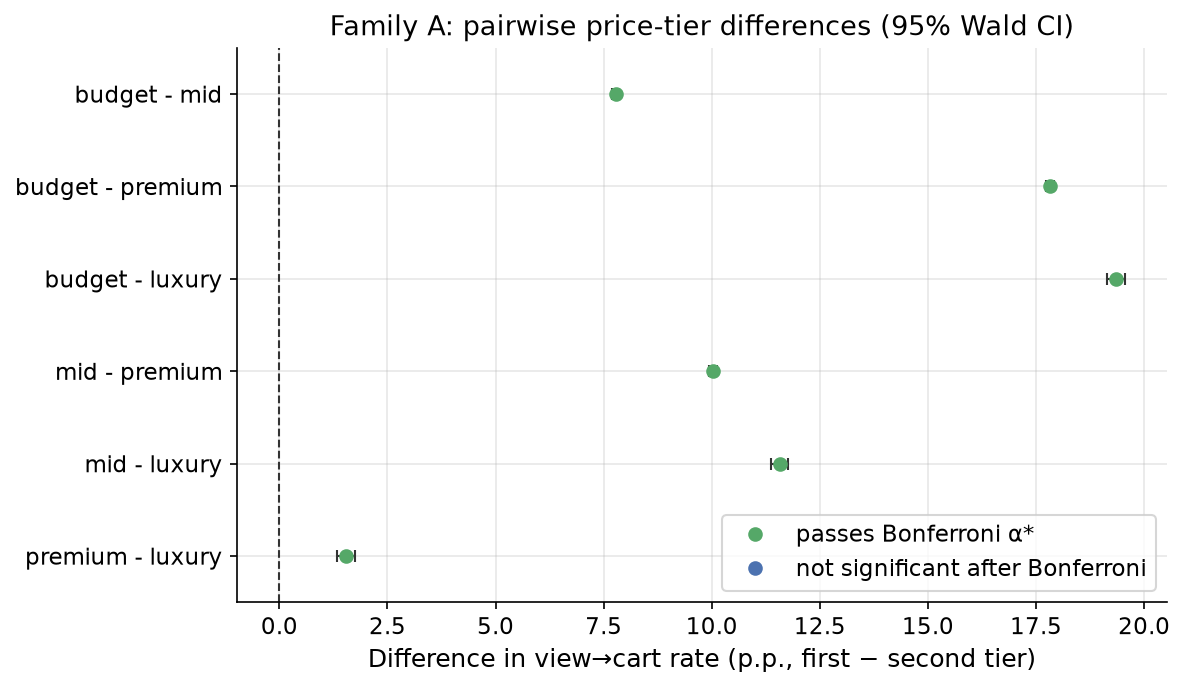

saved /mnt/d/opencode/new20/assets/confirm_price_tier_forest.png


In [5]:
# Forest plot of the six family-A differences (percentage points). Sparse pairs
# would have no CI to draw and are skipped with a count note — honest omission
# beats a fabricated whisker. Colours encode the corrected rejection rule so
# the chart cannot visually over-claim a non-significant gap.
plot_rows = [r for r in pair_results if not r["sparse"]]
n_sparse_skipped = len(pair_results) - len(plot_rows)

fig, ax = plt.subplots(figsize=(8.0, 4.8))
for _yi, _r in enumerate(plot_rows):
    _d = _r["diff"] * 100
    _lo = _r["ci_low"] * 100
    _hi = _r["ci_high"] * 100
    _color = "#55A868" if _r["passes_bonf"] else "#4C72B0"
    ax.errorbar(
        _d, _yi,
        xerr=[[_d - _lo], [_hi - _d]],
        fmt="o", color=_color, ecolor="#333333",
        capsize=3, elinewidth=1, markersize=6, zorder=4,
    )

# Zero line: a CI crossing it is not statistically established at the
# uncorrected level either — the reference the whole chart is read against.
ax.axvline(0.0, color="#333333", linestyle="--", linewidth=1.0, zorder=2)

ax.set_yticks(range(len(plot_rows)))
ax.set_yticklabels([r["pair"] for r in plot_rows])
ax.invert_yaxis()  # first pre-registered pair reads at the top
ax.set_xlabel("Difference in view→cart rate (p.p., first − second tier)")
ax.set_title("Family A: pairwise price-tier differences (95% Wald CI)")
ax.set_ylim(len(plot_rows) - 0.5, -0.5)  # headroom after inversion

# Proxy artists so both colours are explainable in the legend.
_proxy_sig = plt.Line2D(
    [0], [0], marker="o", linestyle="none", color="#55A868",
    markersize=6, label="passes Bonferroni α*",
)
_proxy_ns = plt.Line2D(
    [0], [0], marker="o", linestyle="none", color="#4C72B0",
    markersize=6, label="not significant after Bonferroni",
)
ax.legend(handles=[_proxy_sig, _proxy_ns], loc="lower right")

_forest_out = REPO_ROOT / assets_path("confirm_price_tier_forest")
out_path = Path(_forest_out)
out_path.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_path, dpi=150)
plt.close(fig)
display(Image(filename=str(out_path)))
print(f"saved {out_path}")
if n_sparse_skipped:
    print(f"note: {n_sparse_skipped} sparse pair(s) skipped (no CI to draw)")


In [6]:
# Family B (pre-reg §3): visit kind × cart->purchase on cart sessions only.
# Direction convention is pre-registered: diff = p_new − p_returning, so a
# positive diff means new visitors convert cart→purchase better than returning.
cart = seg.filter(pl.col("has_cart"))
new_cart = cart.filter(pl.col("visit_kind") == "new")
ret_cart = cart.filter(pl.col("visit_kind") == "returning")

fam_b = two_prop_ztest(
    int(new_cart["has_purchase"].sum()), new_cart.height,
    int(ret_cart["has_purchase"].sum()), ret_cart.height,
)
# Single test: α = 0.05, no multiplicity correction applies (pre-reg §4).
fam_b_passes = (
    (not fam_b["sparse"])
    and fam_b["p_value"] is not None
    and fam_b["p_value"] < ALPHA
)
# Affected volume = smaller compared group (§5 gap note): the cart sessions a
# hypothetical action would lift.
fam_b_affected = min(new_cart.height, ret_cart.height)

_lines = [
    "**Family B — visit kind × cart→purchase** (cart sessions; "
    "diff = p_new − p_returning).",
    "",
    "| group | cart sessions | purchase sessions | cart→purchase | 95% Wilson CI |",
    "|---|---:|---:|---:|---:|",
]
for _label, _n, _ev in (
    ("new", new_cart.height, int(new_cart["has_purchase"].sum())),
    ("returning", ret_cart.height, int(ret_cart["has_purchase"].sum())),
):
    _lo, _hi = wilson_ci(_ev, _n)
    _lines.append(
        f"| {_label} | {_n:,} | {_ev:,} | {_ev / _n:.4%} | [{_lo:.4%}, {_hi:.4%}] |"
    )
_lines += ["", f"**z-test result:**"]
if fam_b["sparse"]:
    _lines.append(
        "**SPARSE** (min expected count < 5) → no test per pre-reg §4; "
        "rates above are descriptive only."
    )
else:
    _lines += [
        f"z = {fam_b['z']:.4f}, p = {fam_b['p_value']:.4e}, "
        f"diff = {fam_b['diff'] * 100:+.4f} p.p., "
        f"95% CI [{fam_b['ci_low'] * 100:+.4f}, {fam_b['ci_high'] * 100:+.4f}] p.p. "
        f"— passes α = {ALPHA}: **{'yes' if fam_b_passes else 'no'}**."
    ]
display(Markdown("\n".join(_lines)))


**Family B — visit kind × cart→purchase** (cart sessions; diff = p_new − p_returning).

| group | cart sessions | purchase sessions | cart→purchase | 95% Wilson CI |
|---|---:|---:|---:|---:|
| new | 306,305 | 37,966 | 12.3948% | [12.2786%, 12.5120%] |
| returning | 679,475 | 88,323 | 12.9987% | [12.9190%, 13.0789%] |

**z-test result:**
z = -8.3023, p = 1.0211e-16, diff = -0.6039 p.p., 95% CI [-0.7453, -0.4624] p.p. — passes α = 0.05: **yes**.

In [7]:
# Family C (pre-reg §3): weekend × cart->purchase on cart sessions only.
# Direction: diff = p_weekend − p_weekday; positive = a positive "weekend effect".
we_cart = cart.filter(pl.col("is_weekend"))
wk_cart = cart.filter(pl.col("is_weekend").not_())

fam_c = two_prop_ztest(
    int(we_cart["has_purchase"].sum()), we_cart.height,
    int(wk_cart["has_purchase"].sum()), wk_cart.height,
)
fam_c_passes = (
    (not fam_c["sparse"])
    and fam_c["p_value"] is not None
    and fam_c["p_value"] < ALPHA
)
fam_c_affected = min(we_cart.height, wk_cart.height)

_lines = [
    "**Family C — weekend/weekday × cart→purchase** (cart sessions; "
    "diff = p_weekend − p_weekday).",
    "",
    "| group | cart sessions | purchase sessions | cart→purchase | 95% Wilson CI |",
    "|---|---:|---:|---:|---:|",
]
for _label, _n, _ev in (
    ("weekend", we_cart.height, int(we_cart["has_purchase"].sum())),
    ("weekday", wk_cart.height, int(wk_cart["has_purchase"].sum())),
):
    _lo, _hi = wilson_ci(_ev, _n)
    _lines.append(
        f"| {_label} | {_n:,} | {_ev:,} | {_ev / _n:.4%} | [{_lo:.4%}, {_hi:.4%}] |"
    )
_lines += ["", f"**z-test result:**"]
if fam_c["sparse"]:
    _lines.append(
        "**SPARSE** (min expected count < 5) → no test per pre-reg §4; "
        "rates above are descriptive only."
    )
else:
    _lines += [
        f"z = {fam_c['z']:.4f}, p = {fam_c['p_value']:.4e}, "
        f"diff = {fam_c['diff'] * 100:+.4f} p.p., "
        f"95% CI [{fam_c['ci_low'] * 100:+.4f}, {fam_c['ci_high'] * 100:+.4f}] p.p. "
        f"— passes α = {ALPHA}: **{'yes' if fam_c_passes else 'no'}**."
    ]
display(Markdown("\n".join(_lines)))


**Family C — weekend/weekday × cart→purchase** (cart sessions; diff = p_weekend − p_weekday).

| group | cart sessions | purchase sessions | cart→purchase | 95% Wilson CI |
|---|---:|---:|---:|---:|
| weekend | 255,287 | 31,022 | 12.1518% | [12.0256%, 12.2791%] |
| weekday | 730,493 | 95,267 | 13.0415% | [12.9644%, 13.1189%] |

**z-test result:**
z = -11.5779, p = 5.3339e-31, diff = -0.8897 p.p., 95% CI [-1.0381, -0.7412] p.p. — passes α = 0.05: **yes**.

In [8]:
# Practical-significance gate (pre-reg §5). Decision-relevant (YES) requires
# ALL of: corrected threshold passed AND 95% CI excludes 0 AND |relative
# uplift| >= 10% of the lower rate AND affected volume >= 45,360 sessions.
# SPARSE short-circuits everything: a sparse test was never run (§4).


def _rel_uplift(p_a: float, p_b: float, diff: float) -> float:
    """|diff| relative to the lower (baseline) rate — §5 condition 2."""
    lower = min(p_a, p_b)
    return abs(diff) / lower if lower > 0 else float("inf")


def _gate_verdict(res: dict, passes_threshold: bool, affected_n: int) -> str:
    """Apply the pre-registered decision gate to one z-test result.

    Args:
        res: a two_prop_ztest result dict.
        passes_threshold: True iff the test cleared its corrected threshold
            (Bonferroni for family A; plain α for families B and C).
        affected_n: smaller compared group size (§5 gap-note operand).

    Returns:
        "SPARSE" | "YES" | "NO" — never a bare p-value dressed as a verdict.
    """
    if res["sparse"]:
        return "SPARSE"
    if not passes_threshold:
        return "NO"
    ci_excludes_zero = res["ci_low"] > 0 or res["ci_high"] < 0
    uplift_ok = _rel_uplift(res["p_a"], res["p_b"], res["diff"]) >= 0.10
    volume_ok = affected_n >= VOLUME_MIN
    return "YES" if (ci_excludes_zero and uplift_ok and volume_ok) else "NO"


# One row per pre-registered z-test: 6 family-A pairs + B + C = 8 (asserted).
practical_rows: list[dict] = []
for _r in pair_results:
    _affected = min(tier_stats[_r["a"]]["n"], tier_stats[_r["b"]]["n"])
    practical_rows.append({
        "test": f"A: {_r['pair']} (view→cart)",
        "res": _r,
        "corr_label": f"Bonf α*={ALPHA_STAR:.4f}",
        "passes": _r["passes_bonf"],
        "p_corr": _r["p_bonf"],
        "affected": _affected,
        "verdict": _gate_verdict(_r, _r["passes_bonf"], _affected),
    })

practical_rows.append({
    "test": "B: new − returning (cart→purchase)",
    "res": fam_b,
    "corr_label": f"α={ALPHA} (single test)",
    "passes": fam_b_passes,
    "p_corr": fam_b["p_value"],
    "affected": fam_b_affected,
    "verdict": _gate_verdict(fam_b, fam_b_passes, fam_b_affected),
})
practical_rows.append({
    "test": "C: weekend − weekday (cart→purchase)",
    "res": fam_c,
    "corr_label": f"α={ALPHA} (single test)",
    "passes": fam_c_passes,
    "p_corr": fam_c["p_value"],
    "affected": fam_c_affected,
    "verdict": _gate_verdict(fam_c, fam_c_passes, fam_c_affected),
})

assert len(practical_rows) == 8, (
    f"pre-reg inventory is 8 z-tests (6+1+1), got {len(practical_rows)}"
)


def _fmt_p_cell(p: float | None) -> str:
    """P-value cell for the practical table; None/NaN become an em dash."""
    if p is None or (isinstance(p, float) and math.isnan(p)):
        return "—"
    return f"{p:.3e}"


_lines = [
    "**Practical-significance table** — every pre-registered z-test "
    "(non-rejections included so nothing is silently dropped). "
    f"Omnibus χ² is the family-A gate reported above; the §5 practical rule "
    f"applies to tests that carry a CI of a difference.",
    "",
    "| test | raw p | decision p (rule) | passes threshold | diff (p.p.) | "
    "|rel. uplift| | affected n | **verdict** |",
    "|---|---:|---:|:---:|---:|---:|---:|:---:|",
]
for _row in practical_rows:
    _res = _row["res"]
    if _res["sparse"]:
        _lines.append(
            f"| {_row['test']} | — | — | no | — | — | "
            f"{_row['affected']:,} | **SPARSE** |"
        )
        continue
    _rel = _rel_uplift(_res["p_a"], _res["p_b"], _res["diff"])
    _lines.append(
        f"| {_row['test']} | {_fmt_p_cell(_res['p_value'])} | "
        f"{_fmt_p_cell(_row['p_corr'])} ({_row['corr_label']}) | "
        f"{'yes' if _row['passes'] else 'no'} | "
        f"{_res['diff'] * 100:+.4f} | {_rel:.2%} | "
        f"{_row['affected']:,} | **{_row['verdict']}** |"
    )

_n_yes = sum(1 for _row in practical_rows if _row["verdict"] == "YES")
_n_stat = sum(1 for _row in practical_rows if _row["passes"])
_lines += [
    "",
    f"**{_n_stat} of 8** tests pass their corrected threshold; "
    f"**{_n_yes} of 8** are decision-relevant (**YES**) under the full "
    f"three-part gate. Statistically significant ≠ actionable — that gap is "
    f"the point of this table (golden standard: two kinds of significance).",
]
display(Markdown("\n".join(_lines)))


**Practical-significance table** — every pre-registered z-test (non-rejections included so nothing is silently dropped). Omnibus χ² is the family-A gate reported above; the §5 practical rule applies to tests that carry a CI of a difference.

| test | raw p | decision p (rule) | passes threshold | diff (p.p.) | |rel. uplift| | affected n | **verdict** |
|---|---:|---:|:---:|---:|---:|---:|:---:|
| A: budget - mid (view→cart) | 0.000e+00 | 0.000e+00 (Bonf α*=0.0083) | yes | +7.7800 | 49.08% | 1,853,062 | **YES** |
| A: budget - premium (view→cart) | 0.000e+00 | 0.000e+00 (Bonf α*=0.0083) | yes | +17.8141 | 306.29% | 397,736 | **YES** |
| A: budget - luxury (view→cart) | 0.000e+00 | 0.000e+00 (Bonf α*=0.0083) | yes | +19.3508 | 452.17% | 41,804 | **NO** |
| A: mid - premium (view→cart) | 0.000e+00 | 0.000e+00 (Bonf α*=0.0083) | yes | +10.0341 | 172.52% | 397,736 | **YES** |
| A: mid - luxury (view→cart) | 0.000e+00 | 0.000e+00 (Bonf α*=0.0083) | yes | +11.5708 | 270.38% | 41,804 | **NO** |
| A: premium - luxury (view→cart) | 3.327e-38 | 1.996e-37 (Bonf α*=0.0083) | yes | +1.5367 | 35.91% | 41,804 | **NO** |
| B: new − returning (cart→purchase) | 1.021e-16 | 1.021e-16 (α=0.05 (single test)) | yes | -0.6039 | 4.87% | 306,305 | **NO** |
| C: weekend − weekday (cart→purchase) | 5.334e-31 | 5.334e-31 (α=0.05 (single test)) | yes | -0.8897 | 7.32% | 255,287 | **NO** |

**8 of 8** tests pass their corrected threshold; **3 of 8** are decision-relevant (**YES**) under the full three-part gate. Statistically significant ≠ actionable — that gap is the point of this table (golden standard: two kinds of significance).

In [9]:
# Verdict summary assembled from the result objects above, so the prose can
# never disagree with the executed tests (single source of truth = this kernel
# state). Static contractual statements (boundaries, luxury-by-design, SHA)
# are included here so the reader gets one complete closing block.
_yes_rows = [row for row in practical_rows if row["verdict"] == "YES"]
_stat_rows = [row for row in practical_rows if row["passes"]]

_yes_md = (
    "\n".join(f"- **{row['test']}** — diff {row['res']['diff'] * 100:+.4f} p.p., "
              f"rel. uplift {_rel_uplift(row['res']['p_a'], row['res']['p_b'], row['res']['diff']):.1%}, "
              f"affected {row['affected']:,}"
              for row in _yes_rows)
    if _yes_rows
    else "- **none** — no comparison clears all three practical conditions."
)

_md = f"""\
## Verdict summary (pre-registered decision rule, commit `{PREREG_SHA}`)

**Family A (price tier × view→cart).**
Omnibus χ²(4×2): p = {chi2_res['p_value']:.4e} — H₀
{"rejected" if chi2_res["valid"] and chi2_res["p_value"] < ALPHA else "not rejected"}
at α = {ALPHA}{" (test valid)" if chi2_res["valid"] else " (SPARSE — descriptive only)"}.
Pairwise (Bonferroni α* = {ALPHA_STAR:.4f}): **{sum(1 for r in pair_results if r['passes_bonf'])} of {N_PAIRWISE}**
pass. BH-FDR (sensitivity) agrees or is reported alongside without setting
rejection.

**Family B (visit kind × cart→purchase).**
p = {fam_b['p_value'] if fam_b['p_value'] is not None else float('nan'):.4e} —
{"statistically significant" if fam_b_passes else "not significant"} at α = {ALPHA};
practical verdict: **{next(row['verdict'] for row in practical_rows if row['test'].startswith('B:'))}**.

**Family C (weekend × cart→purchase).**
p = {fam_c['p_value'] if fam_c['p_value'] is not None else float('nan'):.4e} —
{"statistically significant" if fam_c_passes else "not significant"} at α = {ALPHA};
practical verdict: **{next(row['verdict'] for row in practical_rows if row['test'].startswith('C:'))}**.

**Decision-relevant (statistically AND practically significant):**
{_yes_md}

**By design (pre-reg §5).** Luxury (42 438 sessions = 0.94 %) sits below the
1 % affected-volume bar, so **every** pairwise comparison involving luxury is
**not decision-relevant** regardless of its p-value — the gate says “too small
to act on”. That consequence was pinned before any test ran; it is not a
post-hoc rationalisation.

**Boundaries (unchanged).** The overall funnel in notebooks 01/02 remains
**descriptive** — no significance claim attaches to those headline rates
(pre-reg §1). This notebook ran **exactly** the pre-registered inventory
(1 χ² + 6 + 1 + 1 z-tests); **no additional test, no tuning, no deviation**
from `reports/pre_registration.md` @ `{PREREG_SHA}`. Statistics ≠ causation:
every statement above is an association on session-level data, not a causal
effect of tier, visit kind or weekday.
"""
display(Markdown(_md))


## Verdict summary (pre-registered decision rule, commit `35317bc`)

**Family A (price tier × view→cart).**
Omnibus χ²(4×2): p = 0.0000e+00 — H₀
rejected
at α = 0.05 (test valid).
Pairwise (Bonferroni α* = 0.0083): **6 of 6**
pass. BH-FDR (sensitivity) agrees or is reported alongside without setting
rejection.

**Family B (visit kind × cart→purchase).**
p = 1.0211e-16 —
statistically significant at α = 0.05;
practical verdict: **NO**.

**Family C (weekend × cart→purchase).**
p = 5.3339e-31 —
statistically significant at α = 0.05;
practical verdict: **NO**.

**Decision-relevant (statistically AND practically significant):**
- **A: budget - mid (view→cart)** — diff +7.7800 p.p., rel. uplift 49.1%, affected 1,853,062
- **A: budget - premium (view→cart)** — diff +17.8141 p.p., rel. uplift 306.3%, affected 397,736
- **A: mid - premium (view→cart)** — diff +10.0341 p.p., rel. uplift 172.5%, affected 397,736

**By design (pre-reg §5).** Luxury (42 438 sessions = 0.94 %) sits below the
1 % affected-volume bar, so **every** pairwise comparison involving luxury is
**not decision-relevant** regardless of its p-value — the gate says “too small
to act on”. That consequence was pinned before any test ran; it is not a
post-hoc rationalisation.

**Boundaries (unchanged).** The overall funnel in notebooks 01/02 remains
**descriptive** — no significance claim attaches to those headline rates
(pre-reg §1). This notebook ran **exactly** the pre-registered inventory
(1 χ² + 6 + 1 + 1 z-tests); **no additional test, no tuning, no deviation**
from `reports/pre_registration.md` @ `35317bc`. Statistics ≠ causation:
every statement above is an association on session-level data, not a causal
effect of tier, visit kind or weekday.


## What this notebook did — and did not — do

**Did:** executed the three pre-registered families (§3) against the fixed
parameters (§4–§5), reported both statistical and practical significance in
separate columns, and wrote the family-A forest plot to
`assets/confirm_price_tier_forest.png`.

**Did not:** run any test outside the pre-registered list; adjust α, tiers or
thresholds after seeing outcomes; re-label any exploratory pattern from
notebook 03 as confirmatory; or attach a significance claim to the overall
funnel (descriptive by §1).

Any future re-analysis that departs from this document becomes an explicitly
labelled **exploratory post-hoc** study in notebook 06 territory — never a
silent edit of this notebook’s conclusions (§6).
